## Football Prediction by Chutimon C.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
import os


folder_path = "FootballPLDataSeason"

csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
df_list = []

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)
    df_list.append(df)

# Combine into one DataFrame
df = pd.concat(df_list, ignore_index=True)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values(by='Date', ascending=True).reset_index(drop=True)

display(df)

In [ ]:
from matplotlib import pyplot as plt
import pandas as pd

ftr_counts = df['FTR'].value_counts().sort_index()

print(f"The total amount of Matches in Premier League since 1993/94 : {len(df)}")


color_map = {
    'H': 'lightcoral',
    'D': 'thistle',
    'A': 'powderblue'
}

# Map the FTR
bar_colors = [color_map[key] for key in ftr_counts.index]

ax = ftr_counts.plot(kind='barh', color=bar_colors, edgecolor='gray')


new_labels = ['Away Team Wins', 'Draw', 'Home Team Wins']  # Match index order: A, D, H
ax.set_yticks(range(len(new_labels)))
ax.set_yticklabels(new_labels)

for i, value in enumerate(ftr_counts):
    ax.text(value + 1, i, str(value), va='center', fontsize=10)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel("Number of Matches")
plt.ylabel("Results")
plt.title("Premier League matches from 1993/94 to the first round of 2023/24")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define valid seasons
valid_seasons = [f"{str(y)[-2:]}-{str(y+1)[-2:]}" for y in range(1993, 2024)]
df = df[df['Season'].isin(valid_seasons)]


df["home_win"] = (df["FTHG"] > df["FTAG"]).astype(int)
df["draw"] = (df["FTHG"] == df["FTAG"]).astype(int)
df["away_win"] = (df["FTHG"] < df["FTAG"]).astype(int)

#win rates grouped by season
win_rates = (
    df.groupby("Season")[["home_win", "draw", "away_win"]]
    .mean()
    .reindex(valid_seasons, fill_value=0)
)


plt.figure(figsize=(15, 8))
plt.plot(win_rates.index, win_rates["home_win"], marker='o', label="Home Win", color='lightcoral')
plt.plot(win_rates.index, win_rates["draw"], marker='o', label="Draw", color='thistle')
plt.plot(win_rates.index, win_rates["away_win"], marker='o', label="Away Win", color='deepskyblue')

# Add staggered annotations to reduce overlap
for col_idx, col in enumerate(["home_win", "draw", "away_win"]):
    for i, val in enumerate(win_rates[col]):
        offset = 0.01 + (col_idx * 0.005)
        plt.text(i, val + offset, f"{val:.2f}", ha='center', fontsize=8)

#COVID season
if "19-20" in valid_seasons:
    covid_index = valid_seasons.index("19-20")
    plt.axvline(x=covid_index, color='crimson', linestyle='--', linewidth=2, label="COVID Season")


plt.xticks(range(len(valid_seasons)), valid_seasons, rotation=60)
plt.xlabel("Season")
plt.ylabel("Rate")
plt.title("Match Outcome Rates per Season")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

score_range = range(11)


df['FTHG'] = df['FTHG'].astype(int)
df['FTAG'] = df['FTAG'].astype(int)


score_freq = pd.crosstab(df['FTHG'], df['FTAG'])

plt.figure(figsize=(12, 10))
sns.heatmap(score_freq, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Matches'},annot_kws={"size": 10})

plt.title('Scoreline Frequencies in Premier League from 1993/94 to the first round of 2023/24')
plt.xlabel('Away Team Scores')
plt.ylabel('Home Team Scores')
plt.show()


In [ ]:
import pandas as pd
import numpy as np


# Step 1: Select Season
stats_df = df[(df['Season'] >= '18-19')&(df['Season'] <= '23-24')]
stats_df['Date'].dt.day_name()

# Step 2: Compute Average Goals and Attack & Defense strength for Home Team & Away Team
avg_home_goals = stats_df['FTHG'].mean()
avg_away_goals = stats_df['FTAG'].mean()

home_attack = stats_df.groupby('HomeTeam')['FTHG'].mean() / avg_home_goals
home_defense = stats_df.groupby('HomeTeam')['FTAG'].mean() / avg_away_goals
away_attack = stats_df.groupby('AwayTeam')['FTAG'].mean() / avg_away_goals
away_defense = stats_df.groupby('AwayTeam')['FTHG'].mean() / avg_home_goals

# Step 3: Home Team rows
home_rows = stats_df[['Season','Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR']].copy()
home_rows['season'] = home_rows['Season']
home_rows['date'] = home_rows['Date']
home_rows['advantage'] = 'home'
home_rows['team'] = home_rows['HomeTeam']
home_rows['opponent'] = home_rows['AwayTeam']
home_rows['goals(of team)'] = home_rows['FTHG']
home_rows['result'] = home_rows['FTR'].map({'H': 'Team Win', 'A': 'Opponent Win', 'D': 'Draw'})
home_rows['team_attack'] = home_rows['team'].map(home_attack)
home_rows['team_defense'] = home_rows['team'].map(home_defense)
home_rows['opp_attack'] = home_rows['opponent'].map(away_attack)
home_rows['opp_defense'] = home_rows['opponent'].map(away_defense)
home_rows = home_rows[['season','date','advantage','team', 'opponent', 'goals(of team)','result','team_attack','team_defense','opp_attack','opp_defense']]

# Step 4: Away Team rows
away_rows = stats_df[['Season','Date','AwayTeam','HomeTeam','FTAG','FTHG','FTR']].copy()
away_rows['season'] = away_rows['Season']
away_rows['date'] = away_rows['Date']
away_rows['advantage'] = 'away'
away_rows['team'] = away_rows['AwayTeam']
away_rows['opponent'] = away_rows['HomeTeam']
away_rows['goals(of team)'] = away_rows['FTAG']
away_rows['result'] = away_rows['FTR'].map({'A': 'Team Win', 'H': 'Opponent Win', 'D': 'Draw'})
away_rows['team_attack'] = away_rows['team'].map(away_attack)
away_rows['team_defense'] = away_rows['team'].map(away_defense)
away_rows['opp_attack'] = away_rows['opponent'].map(home_attack)
away_rows['opp_defense'] = away_rows['opponent'].map(home_defense)
away_rows = away_rows[['season','date','advantage','team','opponent','goals(of team)','result','team_attack','team_defense','opp_attack','opp_defense']]

# Step 5:Combine both rows
goal_model = pd.concat([home_rows, away_rows], ignore_index=True)

display(goal_model)

In [66]:
display(avg_home_goals)

1.5640350877192983

In [ ]:
display(stats_df.groupby('HomeTeam')['FTHG'].mean())

In [ ]:
display(home_attack)

In [ ]:
selected_matches = goal_model[
    ((goal_model['advantage'] == 'home') & (goal_model['team'] == 'Liverpool') & (goal_model['opponent'] == 'Arsenal')) |
    ((goal_model['advantage'] == 'away') & (goal_model['team'] == 'Arsenal') & (goal_model['opponent'] == 'Liverpool'))
]
display(selected_matches)

In [ ]:
selected_matches_2 = goal_model[
    ((goal_model['advantage'] == 'home') & (goal_model['team'] == 'Arsenal') & (goal_model['opponent'] == 'Liverpool')) |
    ((goal_model['advantage'] == 'away') & (goal_model['team'] == 'Liverpool') & (goal_model['opponent'] == 'Arsenal'))
]
display(selected_matches_2)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

score_range = range(10)

stats_df = stats_df.copy()
stats_df['FTHG'] = stats_df['FTHG'].astype(int)
stats_df['FTAG'] = stats_df['FTAG'].astype(int)

# Create frequency table
score_freq = pd.crosstab(stats_df['FTHG'], stats_df['FTAG'])

# Reindex to ensure axes go from 0 to 9
score_freq = score_freq.reindex(index=score_range, columns=score_range, fill_value=0)

plt.figure(figsize=(12, 10))
sns.heatmap(score_freq, annot=True, fmt='d', cmap='YlGnBu',
            cbar_kws={'label': 'Number of Matches'}, annot_kws={"size": 10})

plt.title('Scoreline Frequencies in Premier League from 2018/19 to the first round of 2023/24')
plt.xlabel('Away Team Scores')
plt.ylabel('Home Team Scores')
plt.xticks(ticks=np.arange(10)+0.5, labels=score_range)
plt.yticks(ticks=np.arange(10)+0.5, labels=score_range, rotation=0)
plt.show()


In [ ]:
# Team Attack vs. Opponent Defense

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.lineplot(x=goal_model.index, y=goal_model['team_attack'], label='Team Attack Strength', color='salmon', alpha=0.7)
sns.lineplot(x=goal_model.index, y=goal_model['opp_defense'], label='Opponent Defense Strength', color='skyblue', alpha=0.7)

plt.title('Team Attack Strength vs. Opponent Defense Strength')
plt.xlabel('Matches')
plt.ylabel('Strength')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Team Defense vs. Opponent Attack

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.lineplot(x=goal_model.index, y=goal_model['team_defense'], label='Team Defense Strength', color='salmon', alpha=0.7)
sns.lineplot(x=goal_model.index, y=goal_model['opp_attack'], label='Opponent Attack Strength', color='skyblue', alpha=0.7)

plt.title('Team Defense Strength vs. Opponent Attack Strength')
plt.xlabel('Matches')
plt.ylabel('Strength')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

poisson_model = smf.glm(formula="Q('goals(of team)') ~ advantage + team + opponent + (team : team_attack) + (opponent : opp_defense)",
                         data=goal_model,
                         family=sm.families.Poisson()).fit()

poisson_model.summary()

In [ ]:
# Residual Deviance
print(f"Residual Deviance: {poisson_model.deviance:.2f}")

# Degrees of freedom
print(f"Degrees of Freedom: {poisson_model.df_resid:.2f}")

# Check Overdispersion
estimated_phi = poisson_model.deviance/poisson_model.df_resid
print(f"Dispersion (φ̂): {estimated_phi:.2f}")

In [84]:
import pandas as pd
from scipy.stats import poisson

def simulate_match(poisson_model, homeTeam, awayTeam, home_attack_series, away_defense_series, away_attack_series, home_defense_series, max_goals):

    home_input = pd.DataFrame({
        'advantage': ['home'],
        'team': [homeTeam],
        'opponent': [awayTeam],
        'team_attack': [home_attack_series.get(homeTeam, 0.0)],  # default 0.0 if team not found
        'opp_defense': [away_defense_series.get(awayTeam, 0.0)]
    })

    away_input = pd.DataFrame({
        'advantage': ['away'],
        'team': [awayTeam],
        'opponent': [homeTeam],
        'team_attack': [away_attack_series.get(awayTeam, 0.0)],  # default 0.0 if team not found
        'opp_defense': [home_defense_series.get(homeTeam, 0.0)]
     })

    #--------------------------------------------------------------------------------------

    # 1. Predict expected goals

    home_expected_goals = poisson_model.predict(home_input).values[0]
    away_expected_goals = poisson_model.predict(away_input).values[0]

    # 2. Compute Scoreline Probability

    team_pred_home = [poisson.pmf(i, home_expected_goals) for i in range(max_goals + 1)]
    team_pred_away = [poisson.pmf(i, away_expected_goals) for i in range(max_goals + 1)]

    return team_pred_home, team_pred_away

In [ ]:
# Check The expected goals of Home Team (Liverpool)

poisson_model.predict(pd.DataFrame(data={
    'team': 'Liverpool',
    'opponent': 'Arsenal',
    'advantage': 'home',
    'team_attack': home_attack.get('Liverpool', 0.0),
    'opp_defense': away_defense.get('Arsenal', 0.0)
}, index=[1]))

In [ ]:
# Check The expected goals of Away Team (Arsenal)

poisson_model.predict(pd.DataFrame(data={
    'team': 'Arsenal',
    'opponent': 'Liverpool',
    'advantage': 'away',
    'team_attack': away_attack.get('Arsenal', 0.0),
    'opp_defense': home_defense.get('Liverpool', 0.0)
}, index=[1]))

In [92]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson

In [94]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

print("Poisson Regression Model :")
print("Season 2018/19 - the first round in 2023/24 :")
print("\n")

#--------------------------------------------------------------------------------------

team_list_home = sorted(stats_df['HomeTeam'].unique())
home_team_widget = widgets.Dropdown(
    options=[None] + team_list_home,
    description='Home Team:',
    style={'description_width': 'initial'}
)

team_list_away = sorted(stats_df['AwayTeam'].unique())
away_team_widget = widgets.Dropdown(
    options=[None] + team_list_away,
    description='Away Team:',
    style={'description_width': 'initial'}
)

#--------------------------------------------------------------------------------------

def update_heatmap(home_team, away_team):
     if home_team and away_team and home_team != away_team:

        team_pred_home, team_pred_away = simulate_match(
            poisson_model,
            home_team,
            away_team,
            home_attack,
            away_defense,
            away_attack,
            home_defense,
            max_goals=9
        )
        result = np.outer(team_pred_home, team_pred_away)

#--------------------------------------------------------------------------------------

        fig, (x1, x2, x3) = plt.subplots(1, 3, figsize=(20, 6))

        lower_triangular_matrix = np.tril(result, -1)
        cx1 = x1.imshow(lower_triangular_matrix, cmap='Reds', interpolation='nearest')
        x1.set_title(f"{home_team} Wins", size=16, fontweight='bold')

        diag_matrix_2d = np.zeros_like(result)
        np.fill_diagonal(diag_matrix_2d, np.diag(result))
        cx2 = x2.imshow(diag_matrix_2d, cmap='RdPu', interpolation='nearest')
        x2.set_title("Draws", size=16, fontweight='bold')

        upper_triangular_matrix = np.triu(result, 1)
        cx3 = x3.imshow(upper_triangular_matrix, cmap='Blues', interpolation='nearest')
        x3.set_title(f"{away_team} Wins", size=16, fontweight='bold')

        for ax in [x1, x2, x3]:
            ax.set_xlabel(f"{away_team} Goals")
            ax.set_ylabel(f"{home_team} Goals")
            ax.set_xticks(np.arange(10))
            ax.set_yticks(np.arange(10))
            ax.set_xticklabels(np.arange(10))
            ax.set_yticklabels(np.arange(10))

        for i in range(10):
            for j in range(10):
                if lower_triangular_matrix[i, j] > 0:
                    x1.text(j, i, f'{lower_triangular_matrix[i, j]:.3f}', ha='center', va='center', color='gray')
                if i == j and diag_matrix_2d[i, i] > 0:
                    x2.text(i, i, f'{diag_matrix_2d[i, i]:.3f}', ha='center', va='center', color='gray')
                if i < j and upper_triangular_matrix[i, j] > 0:
                    x3.text(j, i, f'{upper_triangular_matrix[i, j]:.3f}', ha='center', va='center', color='gray')

        plt.tight_layout()
        plt.show()

#--------------------------------------------------------------------------------------

        # Probability calculations
        hometeam_win_prob = np.sum(np.tril(result, -1))
        draw_prob = np.sum(np.diag(result))
        awayteam_win_prob = np.sum(np.triu(result, 1))

        print("\nPoisson Regression Model :")
        print("Season 2018/19 - the first round in 2023/24 :")
        print(f"\nProbability of {home_team} win : {hometeam_win_prob * 100:.2f}%")
        print(f"Probability of draw : {draw_prob * 100:.2f}%")
        print(f"Probability of {away_team} win : {awayteam_win_prob * 100:.2f}%")

        print("")
        print(f"{home_team} vs. {away_team} :")

        hometeam_win_prob = np.sum(lower_triangular_matrix)
        draw_prob = np.sum(np.diag(result))
        awayteam_win_prob = np.sum(upper_triangular_matrix)

#--------------------------------------------------------------------------------------

        # Expected goals
        goals = np.arange(10)
        home_xg = np.sum(goals * team_pred_home)
        away_xg = np.sum(goals * team_pred_away)

        print(f"\nExpected goals: {home_team} {home_xg:.2f} - {away_xg:.2f} {away_team}")

#--------------------------------------------------------------------------------------

        # Maximum probabilities
        max_home_prob = np.max(lower_triangular_matrix)
        max_draw_prob = np.max(diag_matrix_2d)
        max_away_prob = np.max(upper_triangular_matrix)

        # Find the most likely scorelines
        home_max_score = np.unravel_index(np.argmax(lower_triangular_matrix), lower_triangular_matrix.shape)
        draw_max_score = np.unravel_index(np.argmax(diag_matrix_2d), diag_matrix_2d.shape)
        away_max_score = np.unravel_index(np.argmax(upper_triangular_matrix), upper_triangular_matrix.shape)

        # Calculate the probability of the most likely scorelines
        home_max_prob_percentage = max_home_prob * 100
        draw_max_prob_percentage = max_draw_prob * 100
        away_max_prob_percentage = max_away_prob * 100


        print(f"\n{home_team} Win Scoreline ({home_max_prob_percentage:.2f}%): {home_max_score[0]} - {home_max_score[1]}")
        print(f"Draw Scoreline ({draw_max_prob_percentage:.2f}%): {draw_max_score[0]} - {draw_max_score[1]}")
        print(f"{away_team} Win Scoreline ({away_max_prob_percentage:.2f}%): {away_max_score[0]} - {away_max_score[1]}")

#--------------------------------------------------------------------------------------

interactive_plot = widgets.interactive(update_heatmap, home_team=home_team_widget, away_team=away_team_widget)
display(interactive_plot)

Poisson Regression Model :
Season 2018/19 - the first round in 2023/24 :




interactive(children=(Dropdown(description='Home Team:', options=(None, 'Arsenal', 'Aston Villa', 'Bournemouth…

In [22]:
import pandas as pd
import os


# Load the dataset
file_path = "FootballPLDataSeason/E02324_2.csv"
df_test = pd.read_csv(file_path)


display(df_test)

,Div,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,E0,23-24,2023-12-30,Luton,Chelsea,2,3,A
1,E0,23-24,2023-12-30,Aston Villa,Burnley,3,2,H
2,E0,23-24,2023-12-30,Crystal Palace,Brentford,3,1,H
3,E0,23-24,2023-12-30,Man City,Sheffield United,2,0,H
4,E0,23-24,2023-12-30,Wolves,Everton,3,0,H
...,...,...,...,...,...,...,...,...
187,E0,23-24,2024-05-19,Crystal Palace,Aston Villa,5,0,H
188,E0,23-24,2024-05-19,Liverpool,Wolves,2,0,H
189,E0,23-24,2024-05-19,Luton,Fulham,2,4,A
190,E0,23-24,2024-05-19,Man City,West Ham,3,1,H


The total amount of Matches in the second round in 2023/24 : 192


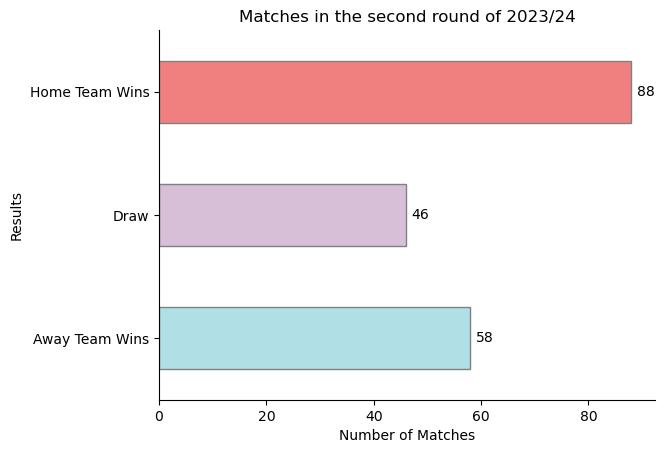

In [23]:
from matplotlib import pyplot as plt

ftr_counts = df_test['FTR'].value_counts().sort_index()

print(f"The total amount of Matches in the second round in 2023/24 : {len(df_test)}")


color_map = {
    'H': 'lightcoral',
    'D': 'thistle',
    'A': 'powderblue'
}

# Map the FTR
bar_colors = [color_map[key] for key in ftr_counts.index]

ax = ftr_counts.plot(kind='barh', color=bar_colors, edgecolor='gray')


new_labels = ['Away Team Wins', 'Draw', 'Home Team Wins']  # Match index order: A, D, H
ax.set_yticks(range(len(new_labels)))
ax.set_yticklabels(new_labels)

for i, value in enumerate(ftr_counts):
    ax.text(value + 1, i, str(value), va='center', fontsize=10)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel("Number of Matches")
plt.ylabel("Results")
plt.title("Matches in the second round of 2023/24")
plt.show()

In [24]:
import numpy as np
import pandas as pd


# 1. Prediction Table

poisson_preds = []

for idx, row in df_test.iterrows():
    season = row['Season']
    home_team = row['HomeTeam']
    away_team = row['AwayTeam']
    real_result = row['FTR']

    team_pred_home, team_pred_away = simulate_match(
        poisson_model,
        home_team,
        away_team,
        home_attack,
        away_defense,
        away_attack,
        home_defense,
        max_goals=9
    )

    result_matrix = np.outer(team_pred_home, team_pred_away)

    home_team_wins_prob = np.sum(np.tril(result_matrix, -1)) * 100
    draw_prob = np.sum(np.diag(result_matrix)) * 100
    away_team_wins_prob = np.sum(np.triu(result_matrix, 1)) * 100


    predicted_data = {
        'Season': season,
        'Home Team': home_team,
        'Away Team': away_team,
        'FTR': real_result,
        '% Home Team Win by Poisson': home_team_wins_prob,
        '% Draw by Poisson': draw_prob,
        '% Away Team Win by Poisson': away_team_wins_prob
    }

    poisson_preds.append(predicted_data)

poisson_preds_df = pd.DataFrame(poisson_preds)

# ----------------------------------------------------------------------

# 2. Highlight on Maximum and Wrong prediction

prob_cols_display = ['% Home Team Win by Poisson', '% Draw by Poisson', '% Away Team Win by Poisson']

def highlight_predictions(row):

    colors = [''] * len(row)
    predicted_probs = [row[col] for col in prob_cols_display]
    predicted_outcome = ['H', 'D', 'A'][np.argmax(predicted_probs)]
    actual_result = row['FTR']

    # Maximum Prediction

    for col in prob_cols_display:
        idx = row.index.get_loc(col)
        if row[col] == max(predicted_probs):
            colors[idx] = 'background-color: lightgreen'

    # Wrong Prediction

    if predicted_outcome != actual_result:
        result_to_col = {'H': '% Home Team Win by Poisson',
                         'D': '% Draw by Poisson',
                         'A': '% Away Team Win by Poisson'}
        correct_col = result_to_col.get(actual_result)
        if correct_col:
            idx = row.index.get_loc(correct_col)
            colors[idx] = 'background-color: lightcoral'

    return colors

styled_df = poisson_preds_df.style.apply(highlight_predictions, axis=1)
display(styled_df)

# ----------------------------------------------------------------------

# 3. Accuracy Correction

correct_predictions = 0

for _, row in poisson_preds_df.iterrows():
    predicted_probs = [row[col] for col in prob_cols_display]
    predicted_result = ['H', 'D', 'A'][np.argmax(predicted_probs)]
    if row['FTR'] == predicted_result:
        correct_predictions += 1

total_matches = len(poisson_preds_df)
accuracy = correct_predictions / total_matches * 100

print("\nSeason 2018/19 - the first round in 2023/24 :")
print(f"Number of correct predictions by Poisson Regression : {correct_predictions} out of {total_matches}")
print(f"Accuracy : {accuracy:.2f}%")


,Season,Home Team,Away Team,FTR,% Home Team Win by Poisson,% Draw by Poisson,% Away Team Win by Poisson
0,23-24,Luton,Chelsea,A,20.808804,19.141118,60.032267
1,23-24,Aston Villa,Burnley,H,52.082610,23.650530,24.265365
2,23-24,Crystal Palace,Brentford,H,36.258205,26.749000,36.992604
3,23-24,Man City,Sheffield United,H,90.161308,7.235991,2.381470
4,23-24,Wolves,Everton,H,42.947825,28.483753,28.568324
5,23-24,Nott'm Forest,Man United,H,32.596168,24.833101,42.570092
6,23-24,Fulham,Arsenal,H,19.004845,22.134965,58.857252
7,23-24,Tottenham,Bournemouth,H,71.486177,16.132796,12.345211
8,23-24,Liverpool,Newcastle,H,75.039520,15.536829,9.396685
9,23-24,West Ham,Brighton,D,43.247140,24.912058,31.840179



Season 2018/19 - the first round in 2023/24 :
Number of correct predictions by Poisson Regression : 112 out of 192
Accuracy : 58.33%


In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

actual_results = []
predicted_results = []

# ----------------------------------------------------------------------

for _, row in poisson_preds_df.iterrows():
    actual_result = row['FTR']
    predicted_probs = [
        row['% Home Team Win by Poisson'],
        row['% Draw by Poisson'],
        row['% Away Team Win by Poisson']
    ]
    predicted_outcome = ['H', 'D', 'A'][np.argmax(predicted_probs)]

    actual_results.append(actual_result)
    predicted_results.append(predicted_outcome)


correct_predictions = sum(a == p for a, p in zip(actual_results, predicted_results))
total_matches = len(actual_results)
accuracy = correct_predictions / total_matches * 100

# ----------------------------------------------------------------------

print("Season 2018/19 - the first round in 2023/24 :")
print(f"\nNumber of correct predictions by Poisson Regression : {correct_predictions} out of {total_matches}")
print(f"Accuracy: {accuracy:.2f}%\n")

labels = ['H', 'D', 'A']
conf_matrix = confusion_matrix(actual_results, predicted_results, labels=labels)
print("Confusion Matrix (rows = actual, columns = predicted) :")
print(conf_matrix)

print("\nClassification Report :")
print(classification_report(actual_results, predicted_results, labels=labels, target_names=['Home Team Win', 'Draw', 'Away Team Win']))

Season 2018/19 - the first round in 2023/24 :

Number of correct predictions by Poisson Regression : 112 out of 192
Accuracy: 58.33%

Confusion Matrix (rows = actual, columns = predicted) :
[[74  0 14]
 [29  0 17]
 [20  0 38]]

Classification Report :
               precision    recall  f1-score   support

Home Team Win       0.60      0.84      0.70        88
         Draw       0.00      0.00      0.00        46
Away Team Win       0.55      0.66      0.60        58

     accuracy                           0.58       192
    macro avg       0.38      0.50      0.43       192
 weighted avg       0.44      0.58      0.50       192



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
#df_test home team rows

avg_home_goals = df_test['FTHG'].mean()
avg_away_goals = df_test['FTAG'].mean()


home_attack = df_test.groupby('HomeTeam')['FTHG'].mean() / avg_home_goals
home_defense = df_test.groupby('HomeTeam')['FTAG'].mean() / avg_away_goals
away_attack = df_test.groupby('AwayTeam')['FTAG'].mean() / avg_away_goals
away_defense = df_test.groupby('AwayTeam')['FTHG'].mean() / avg_home_goals

home_rows = df_test[['Season','HomeTeam','AwayTeam','FTHG','FTAG','FTR']].copy()
home_rows['season (2nd round)'] = home_rows['Season']
home_rows['team'] = home_rows['HomeTeam']
home_rows['opponent'] = home_rows['AwayTeam']
home_rows['goals (of team)'] = home_rows['FTHG']
home_rows['result'] = home_rows['FTR'].map({'H': 'Team Win', 'A': 'Opponent Win', 'D': 'Draw'})
home_rows['advantage'] = 'home'
home_rows['team_attack'] = home_rows['team'].map(home_attack)
home_rows['opp_defense'] = home_rows['opponent'].map(away_defense)
home_rows = home_rows[['season (2nd round)','advantage','team','opponent','goals (of team)','result']]

#df_test away team rows

away_rows = df_test[['Season','AwayTeam','HomeTeam','FTAG','FTHG','FTR']].copy()
away_rows['season (2nd round)'] = away_rows['Season']
away_rows['team'] = away_rows['AwayTeam']
away_rows['opponent'] = away_rows['HomeTeam']
away_rows['goals (of team)'] = away_rows['FTAG']
away_rows['result'] = away_rows['FTR'].map({'A': 'Team Win', 'H': 'Opponent Win', 'D': 'Draw'})
away_rows['advantage'] = 'away'
away_rows['team_attack'] = away_rows['team'].map(home_attack)
away_rows['opp_defense'] = away_rows['opponent'].map(away_defense)

away_rows = away_rows[['season (2nd round)','advantage','team','opponent','goals (of team)','result']]
new_df_test = pd.concat([home_rows, away_rows], ignore_index=True)

display(new_df_test)

,season (2nd round),advantage,team,opponent,goals (of team),result
0,23-24,home,Luton,Chelsea,2,Opponent Win
1,23-24,home,Aston Villa,Burnley,3,Team Win
2,23-24,home,Crystal Palace,Brentford,3,Team Win
3,23-24,home,Man City,Sheffield United,2,Team Win
4,23-24,home,Wolves,Everton,3,Team Win
...,...,...,...,...,...,...
379,23-24,away,Aston Villa,Crystal Palace,0,Opponent Win
380,23-24,away,Wolves,Liverpool,0,Opponent Win
381,23-24,away,Fulham,Luton,4,Team Win
382,23-24,away,West Ham,Man City,1,Opponent Win


In [27]:
import numpy as np
import pandas as pd


# 1. Prediction Table

poisson_preds = []

for idx, row in new_df_test.iterrows():
    season = row['season (2nd round)']
    advantage = row['advantage']
    team = row['team']
    opponent = row['opponent']
    real_result = row['result']

    # --------------------------------------------------

    if advantage == 'home':
        home_team = team
        away_team = opponent
    else: # advantage == 'away'
        home_team = opponent
        away_team = team

    # --------------------------------------------------

    team_pred_home, team_pred_away = simulate_match(
        poisson_model,
        home_team,
        away_team,
        home_attack,
        away_defense,
        away_attack,
        home_defense,
        max_goals=9
    )

    result_matrix = np.outer(team_pred_home, team_pred_away)

    home_team_wins_prob = np.sum(np.tril(result_matrix, -1)) * 100
    draw_prob = np.sum(np.diag(result_matrix)) * 100
    away_team_wins_prob = np.sum(np.triu(result_matrix, 1)) * 100

    # --------------------------------------------------

    if advantage == 'home':
        team_wins_prob      = home_team_wins_prob
        opponent_wins_prob  = away_team_wins_prob
    else:  # advantage == 'away'
        team_wins_prob      = away_team_wins_prob
        opponent_wins_prob  = home_team_wins_prob

    # --------------------------------------------------

    predicted_data = {
        'season (2nd round)': season,
        'advantage': advantage,
        'team': team,
        'opponent': opponent,
        'result': real_result,
        '% Team Win by Poisson': team_wins_prob,
        '% Draw by Poisson': draw_prob,
        '% Opponent Win by Poisson': opponent_wins_prob
    }

    poisson_preds.append(predicted_data)

poisson_preds_df = pd.DataFrame(poisson_preds)

# ----------------------------------------------------------------------

# 2. Highlight on Maximum and Wrong prediction

prob_cols_display = ['% Team Win by Poisson', '% Draw by Poisson', '% Opponent Win by Poisson']

def highlight_predictions(row):

    colors = [''] * len(row)
    predicted_probs = [row[col] for col in prob_cols_display]
    predicted_outcome = ['Team Win', 'Draw', 'Opponent Win'][np.argmax(predicted_probs)]
    actual_result = row['result']

    # Maximum Prediction

    for col in prob_cols_display:
        idx = row.index.get_loc(col)
        if row[col] == max(predicted_probs):
            colors[idx] = 'background-color: lightgreen'

    # Wrong Prediction

    if predicted_outcome != actual_result:
        result_to_col = {'Team Win': '% Team Win by Poisson',
                         'Draw': '% Draw by Poisson',
                         'Opponent Win': '% Opponent Win by Poisson'}
        correct_col = result_to_col.get(actual_result)
        if correct_col:
            idx = row.index.get_loc(correct_col)
            colors[idx] = 'background-color: lightcoral'

    return colors

styled_df = poisson_preds_df.style.apply(highlight_predictions, axis=1)
display(styled_df)

# ----------------------------------------------------------------------

# 3. Accuracy Correction

correct_predictions = 0

for _, row in poisson_preds_df.iterrows():
    predicted_probs = [row[col] for col in prob_cols_display]
    predicted_result = ['Team Win', 'Draw', 'Opponent Win'][np.argmax(predicted_probs)]
    if row['result'] == predicted_result:
        correct_predictions += 1

total_matches = len(poisson_preds_df)
accuracy = correct_predictions / total_matches * 100

print("\nSeason 2018/19 - the first round in 2023/24 :")
print(f"Number of correct predictions by Poisson Regression : {correct_predictions} out of {total_matches}")
print(f"Accuracy : {accuracy:.2f}%")

,season (2nd round),advantage,team,opponent,result,% Team Win by Poisson,% Draw by Poisson,% Opponent Win by Poisson
0,23-24,home,Luton,Chelsea,Opponent Win,28.517205,19.839155,51.627338
1,23-24,home,Aston Villa,Burnley,Team Win,44.893863,21.295413,33.804533
2,23-24,home,Crystal Palace,Brentford,Team Win,73.018621,14.268722,12.594866
3,23-24,home,Man City,Sheffield United,Team Win,85.930516,10.489174,3.520152
4,23-24,home,Wolves,Everton,Team Win,34.712351,28.008952,37.278601
5,23-24,home,Nott'm Forest,Man United,Team Win,37.413895,24.583536,38.001882
6,23-24,home,Fulham,Arsenal,Team Win,6.981626,17.195885,75.815361
7,23-24,home,Tottenham,Bournemouth,Team Win,58.801703,22.817254,18.379032
8,23-24,home,Liverpool,Newcastle,Team Win,63.325978,17.597156,19.037439
9,23-24,home,West Ham,Brighton,Draw,37.755528,31.480701,30.763752



Season 2018/19 - the first round in 2023/24 :
Number of correct predictions by Poisson Regression : 242 out of 384
Accuracy : 63.02%


In [28]:
# Check Accuracy of Team as Home Team

home_predictions = poisson_preds_df[poisson_preds_df['advantage'] == 'home']

home_correct_predictions = 0

for _, row in home_predictions.iterrows():
    predicted_probs = [row[col] for col in prob_cols_display]
    predicted_result = ['Team Win', 'Draw', 'Opponent Win'][np.argmax(predicted_probs)]
    if row['result'] == predicted_result:
        home_correct_predictions += 1

total_matches = len(home_predictions)
home_accuracy = home_correct_predictions / total_matches * 100

print("\nSeason 2018/19 - the first round in 2023/24 :")
print(f"\nNumber of correct predictions for team = Home Team by Poisson Regression : {home_correct_predictions} out of {total_matches}")
print(f"Accuracy for team = Home Team : {home_accuracy:.2f}%")


Season 2018/19 - the first round in 2023/24 :

Number of correct predictions for team = Home Team by Poisson Regression : 121 out of 192
Accuracy for team = Home Team : 63.02%


In [29]:
# Check Accuracy of Team as Away Team

away_predictions = poisson_preds_df[poisson_preds_df['advantage'] == 'away']

away_correct_predictions = 0

for _, row in away_predictions.iterrows():
    predicted_probs = [row[col] for col in prob_cols_display]
    predicted_result = ['Team Win', 'Draw', 'Opponent Win'][np.argmax(predicted_probs)]
    if row['result'] == predicted_result:
        away_correct_predictions += 1

total_matches = len(away_predictions)
away_accuracy = away_correct_predictions / total_matches * 100

print("\nSeason 2018/19 - the first round in 2023/24 :")
print(f"\nNumber of correct predictions for team = Away Team by Poisson Regression : {away_correct_predictions} out of {total_matches}")
print(f"Accuracy for team = Away Team : {away_accuracy:.2f}%")


Season 2018/19 - the first round in 2023/24 :

Number of correct predictions for team = Away Team by Poisson Regression : 121 out of 192
Accuracy for team = Away Team : 63.02%


In [30]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

actual_results = []
predicted_results = []

# ----------------------------------------------------------------------

for _, row in poisson_preds_df.iterrows():
    actual_result = row['result']
    predicted_probs = [
        row['% Team Win by Poisson'],
        row['% Draw by Poisson'],
        row['% Opponent Win by Poisson']
    ]
    predicted_outcome = ['Team Win', 'Draw', 'Opponent Win'][np.argmax(predicted_probs)]

    actual_results.append(actual_result)
    predicted_results.append(predicted_outcome)


correct_predictions = sum(a == p for a, p in zip(actual_results, predicted_results))
total_matches = len(actual_results)
accuracy = correct_predictions / total_matches * 100

# ----------------------------------------------------------------------

print("Season 2018/19 - the first round in 2023/24 :")
print(f"\nNumber of correct predictions by Poisson Regression : {correct_predictions} out of {total_matches}")
print(f"Accuracy : {accuracy:.2f}%\n")

labels = ['Team Win', 'Draw', 'Opponent Win']
conf_matrix = confusion_matrix(actual_results, predicted_results, labels=labels)
print("Confusion Matrix (rows = actual, columns = predicted) :")
print(conf_matrix)

print("\nClassification Report :")
print(classification_report(actual_results, predicted_results, labels=labels, target_names=['Team Win', 'Draw', 'Opponent Win']))

Season 2018/19 - the first round in 2023/24 :

Number of correct predictions by Poisson Regression : 242 out of 384
Accuracy : 63.02%

Confusion Matrix (rows = actual, columns = predicted) :
[[121   1  24]
 [ 46   0  46]
 [ 24   1 121]]

Classification Report :
              precision    recall  f1-score   support

    Team Win       0.63      0.83      0.72       146
        Draw       0.00      0.00      0.00        92
Opponent Win       0.63      0.83      0.72       146

    accuracy                           0.63       384
   macro avg       0.42      0.55      0.48       384
weighted avg       0.48      0.63      0.55       384



In [31]:
# Check Confusion Matrix of Team as Home Team

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

home_actual_results = []
home_predicted_results = []

home_predictions = poisson_preds_df[poisson_preds_df['advantage'] == 'home']

# ----------------------------------------------------------------------

for _, row in home_predictions.iterrows():
    actual_result = row['result']
    predicted_probs = [
        row['% Team Win by Poisson'],
        row['% Draw by Poisson'],
        row['% Opponent Win by Poisson']
    ]
    predicted_outcome = ['Team Win', 'Draw', 'Opponent Win'][np.argmax(predicted_probs)]

    home_actual_results.append(actual_result)
    home_predicted_results.append(predicted_outcome)


home_correct_predictions = sum(a == p for a, p in zip(home_actual_results, home_predicted_results))
total_matches = len(home_actual_results)
home_accuracy = home_correct_predictions / total_matches * 100

# ----------------------------------------------------------------------

print("Season 2018/19 - the first round in 2023/24 :")
print(f"\nNumber of correct predictions by Poisson Regression : {home_correct_predictions} out of {total_matches}")
print(f"Accuracy : {home_accuracy:.2f}%\n")

labels = ['Team Win', 'Draw', 'Opponent Win']
home_confusion_matrix = confusion_matrix(home_actual_results, home_predicted_results, labels=labels)
print("Confusion Matrix (rows = actual, columns = predicted) :")
print(home_confusion_matrix)

print("\nClassification Report :")
print(classification_report(home_actual_results, home_predicted_results, labels=labels, target_names=['team = Home Team Win', 'Draw', 'opponent = Away Team Win']))

Season 2018/19 - the first round in 2023/24 :

Number of correct predictions by Poisson Regression : 121 out of 192
Accuracy : 63.02%

Confusion Matrix (rows = actual, columns = predicted) :
[[74  1 13]
 [24  0 22]
 [11  0 47]]

Classification Report :
                          precision    recall  f1-score   support

    team = Home Team Win       0.68      0.84      0.75        88
                    Draw       0.00      0.00      0.00        46
opponent = Away Team Win       0.57      0.81      0.67        58

                accuracy                           0.63       192
               macro avg       0.42      0.55      0.47       192
            weighted avg       0.48      0.63      0.55       192



In [32]:
# Check Confusion Matrix of Team as Away Team

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

away_actual_results = []
away_predicted_results = []

away_predictions = poisson_preds_df[poisson_preds_df['advantage'] == 'away']

# ----------------------------------------------------------------------

for _, row in away_predictions.iterrows():
    actual_result = row['result']
    predicted_probs = [
        row['% Team Win by Poisson'],
        row['% Draw by Poisson'],
        row['% Opponent Win by Poisson']
    ]
    predicted_outcome = ['Team Win', 'Draw', 'Opponent Win'][np.argmax(predicted_probs)]

    away_actual_results.append(actual_result)
    away_predicted_results.append(predicted_outcome)


away_correct_predictions = sum(a == p for a, p in zip(away_actual_results, away_predicted_results))
total_matches = len(away_actual_results)
away_accuracy = away_correct_predictions / total_matches * 100

# ----------------------------------------------------------------------

print("Season 2018/19 - the first round in 2023/24 :")
print(f"\nNumber of correct predictions for team = Away Team by Poisson Regression : {away_correct_predictions} out of {total_matches}")
print(f"Accuracy for Away Team : {away_accuracy:.2f}%\n")

labels = ['Team Win', 'Draw', 'Opponent Win']
away_confusion_matrix = confusion_matrix(away_actual_results, away_predicted_results, labels=labels)
print("Confusion Matrix for team = Away Team (rows = actual, columns = predicted) :")
print(away_confusion_matrix)

print("\nClassification Report for team = Away Team :")
print(classification_report(away_actual_results, away_predicted_results, labels=labels, target_names=['team = Away Team Win', 'Draw', 'opponent = Home Team Win']))

Season 2018/19 - the first round in 2023/24 :

Number of correct predictions for team = Away Team by Poisson Regression : 121 out of 192
Accuracy for Away Team : 63.02%

Confusion Matrix for team = Away Team (rows = actual, columns = predicted) :
[[47  0 11]
 [22  0 24]
 [13  1 74]]

Classification Report for team = Away Team :
                          precision    recall  f1-score   support

    team = Away Team Win       0.57      0.81      0.67        58
                    Draw       0.00      0.00      0.00        46
opponent = Home Team Win       0.68      0.84      0.75        88

                accuracy                           0.63       192
               macro avg       0.42      0.55      0.47       192
            weighted avg       0.48      0.63      0.55       192

